##### ARTI 560 - Computer Vision

## Instance Segmentation - Exercise 

### Objective

In this exercise, you will implement **Instance Object Segmentation** using a pretrained **Mask R-CNN model** from TensorFlow Hub.

You will follow these steps:

1. **Load the pretrained Mask R-CNN model**  
   - Use this Kaggle link: [Mask R-CNN Inception-ResNet-v2](https://www.kaggle.com/models/tensorflow/mask-rcnn-inception-resnet-v2)  

2. **Select and load 5 different images**  
   - Choose **5 diverse images**, including:  
      - Crowded scenes with multiple objects  
      - Unusual angles, lighting conditions, or occlusions  
      - At least **one image containing multiple objects of the same class** 

3. **Perform inference using the model**  
   - Feed images to the model to obtain predictions  

4. **Extract prediction outputs**  
   - **Bounding boxes** – coordinates of detected objects  
   - **Class labels** – names of detected objects  
   - **Segmentation masks** – pixel-wise masks for each object  

5. **Visualize the results**  
   - Overlay masks on detected objects  
   - Draw bounding boxes around objects  
   - Display class names and confidence scores  

6. **Experiment with confidence thresholds**  
   - Default threshold: **0.5**  
   - Lower threshold: **0.3** to detect more objects (may include false positives)  

---

- Keep in mind:  
  - Some objects may not be recognized at the default threshold 
  - The model only detects objects from the **COCO dataset (80 classes)**  


In [ ]:
!pip install tensorflow tensorflow_hub opencv-python matplotlib

In [2]:
# Import Laibraries
import tensorflow as tf
import tensorflow_hub as hub
import numpy as np
import cv2
import matplotlib.pyplot as plt
import requests
import random

In [3]:
# Load the pre-trained Mask R-CNN model
model = hub.load("https://www.kaggle.com/models/tensorflow/mask-rcnn-inception-resnet-v2/TensorFlow2/1024x1024/1")

In [4]:
# Load the images
def load_images(path):
    image = cv2.imread(path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    return image

image_paths = [
    "/content/images/bicycle.jpg", 
    "/content/images/birds.jpg",
    "/content/images/chairs.jfif",
    "/content/images/people.jpg",
    "/content/images/traffic_light.jpg"
] 
images = [load_images(p) for p in image_paths]

In [5]:
# Run the model on the images
def run_model(image):
    input_tensor = tf.convert_to_tensor(image)
    input_tensor = input_tensor[tf.newaxis, ...]

    outputs = model(input_tensor)

    return outputs

In [6]:
# Extract prediction outputs
def extract_predictions(outputs):
    boxes = outputs['detection_boxes'][0].numpy()
    classes = outputs['detection_classes'][0].numpy().astype(int)
    scores = outputs['detection_scores'][0].numpy()
    masks = outputs['detection_masks'][0].numpy()

    return boxes, classes, scores, masks

In [7]:
# Load COCO classes name
classes_url = "https://raw.githubusercontent.com/amikelive/coco-labels/master/coco-labels-paper.txt"
classes_name = requests.get(classes_url).text.splitlines()

In [8]:
# Visualize results
def visualize_result(image, boxes, classes, scores, masks, threshold=0.5):
    h, w, _ = image.shape
    output = image.copy()

    # Assign a random color for each detected object
    colors = []
    for _ in range(len(scores)):
        colors.append([random.randint(0,255), random.randint(0,255), random.randint(0,255)])

    for i in range(len(scores)):
        if scores[i] < threshold:
            continue

        # Convert class ID to int and get class name
        label_index = int(classes[i]) - 1 
        if label_index < 0 or label_index >= len(classes_name):
            label = "unknown"
        else:
            label = classes_name[label_index]

        y1, x1, y2, x2 = boxes[i]
        y1, x1, y2, x2 = int(y1*h), int(x1*w), int(y2*h), int(x2*w)

        box_h = y2 - y1
        box_w = x2 - x1
        score = scores[i]

        # Draw bounding box
        cv2.rectangle(output, (x1, y1), (x2, y2), colors[i], 2)
        cv2.putText(output, f"{label}: {score:.2f}", (x1, y1-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, colors[i], 2)

        # Resize mask to match image
        mask = cv2.resize(masks[i], (box_w, box_h))
        mask = mask > 0.5

        # Apply mask only inside bounding box
        colored_mask = np.zeros_like(output[y1:y2, x1:x2])
        colored_mask[mask] = colors[i]
        output[y1:y2, x1:x2][mask] = (output[y1:y2, x1:x2][mask] * 0.5 + colored_mask[mask] * 0.5)
    
    plt.figure(figsize=(16,8))
    plt.subplot(1,2,1)
    plt.imshow(image)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(output.astype(np.uint8))
    plt.title("Segmented Image")
    plt.axis("off")
    plt.show()

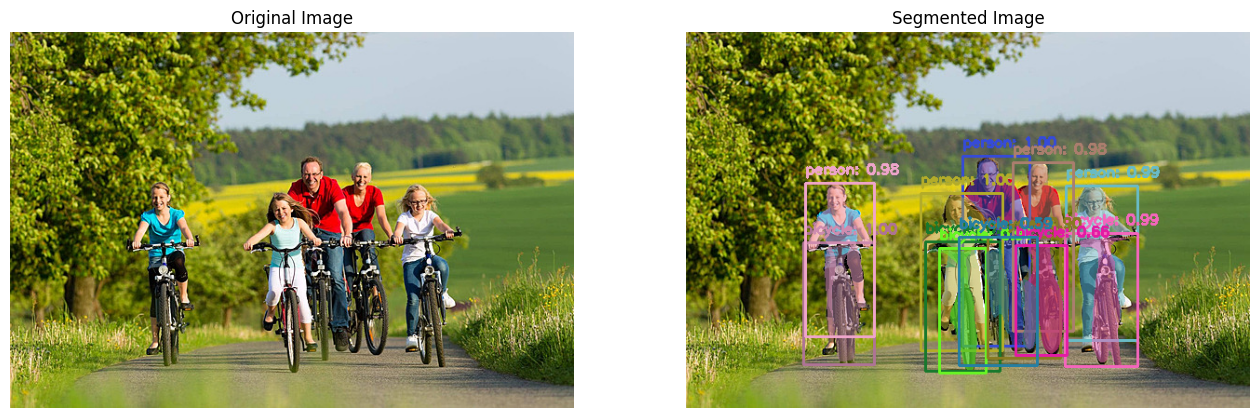

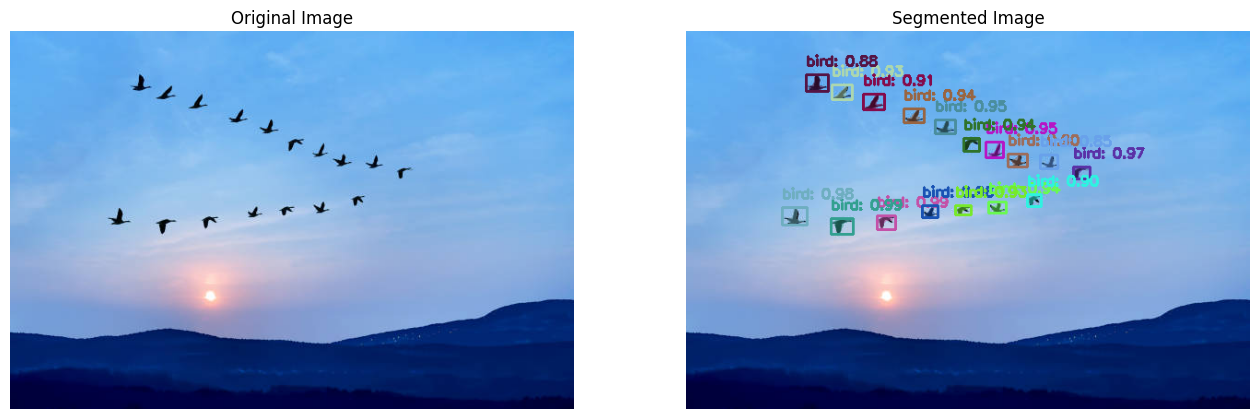

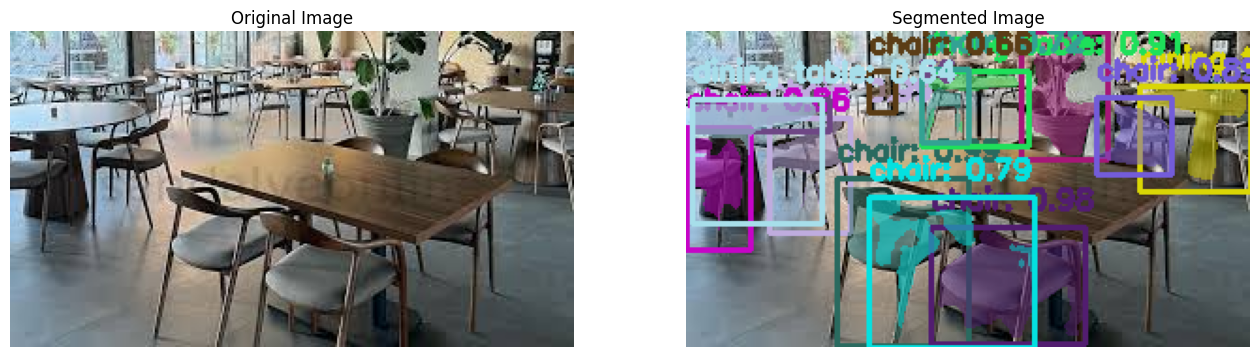

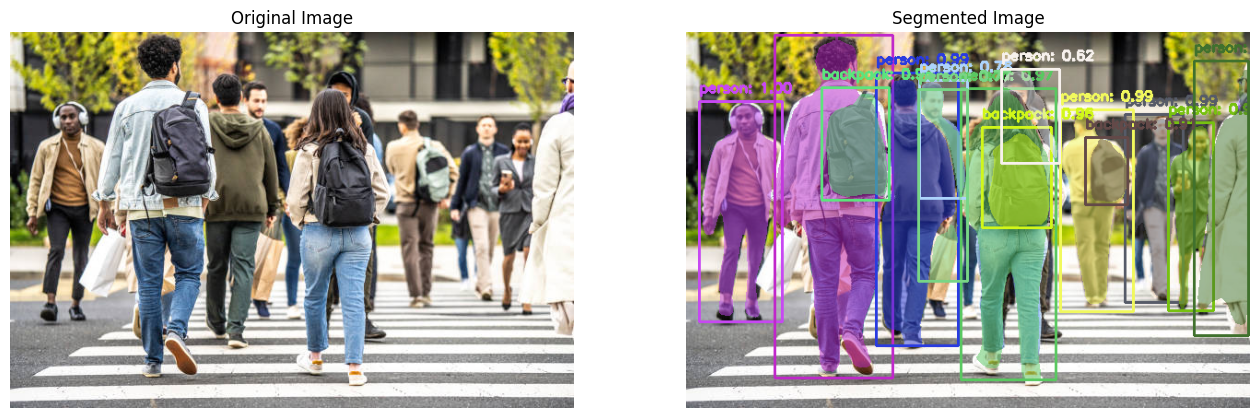

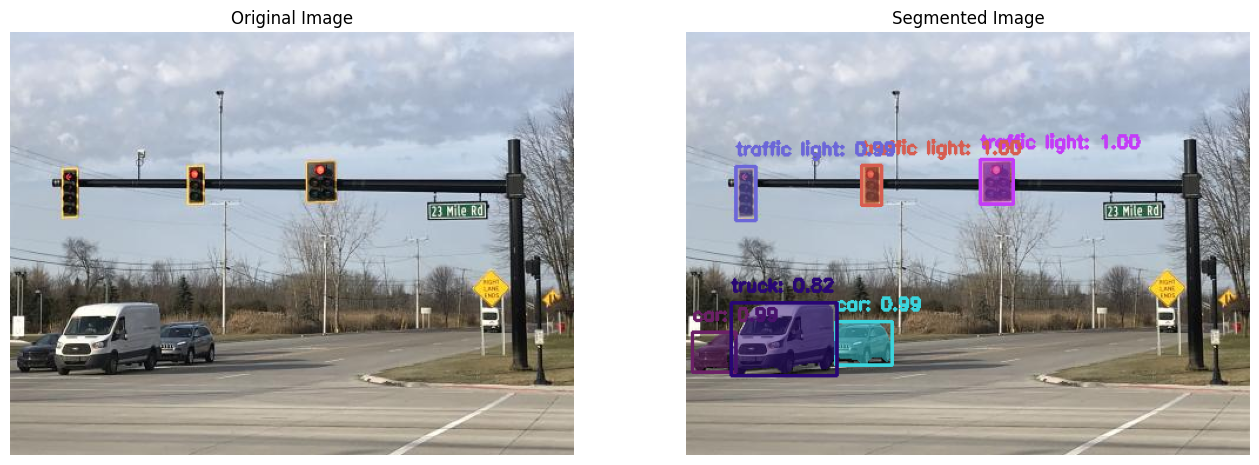

In [9]:
# Process each image with 0.5 thershold
for img in images:
    outputs = run_model(img)
    boxes, classes, scores, masks = extract_predictions(outputs)

    visualize_result(img, boxes, classes, scores, masks, threshold=0.5)

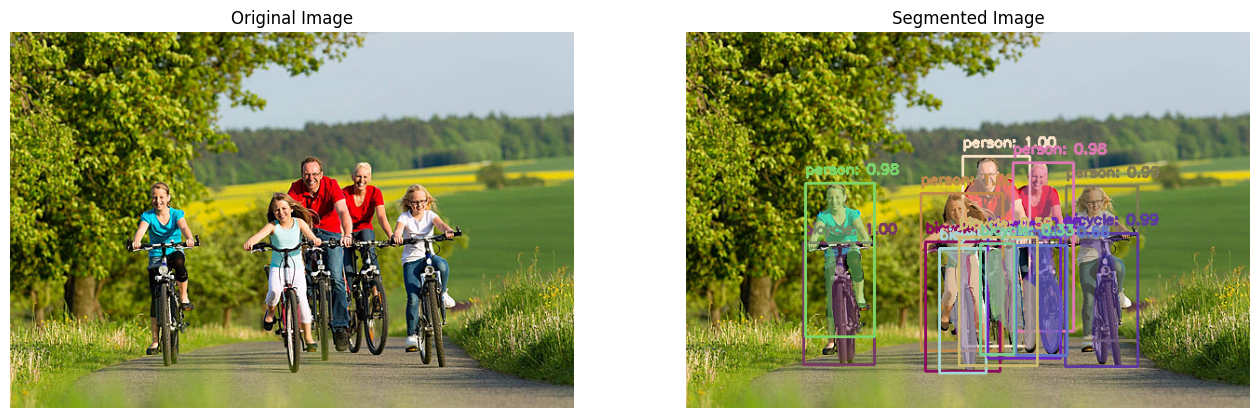

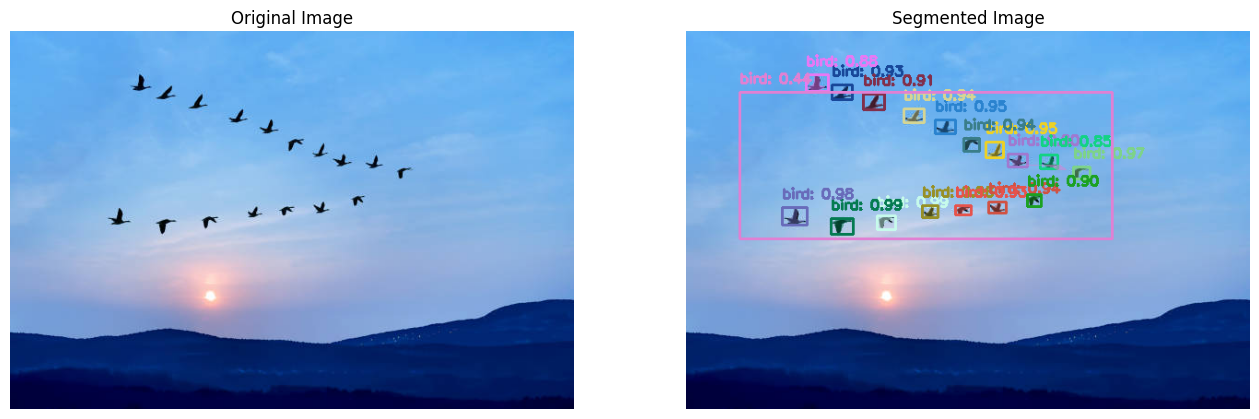

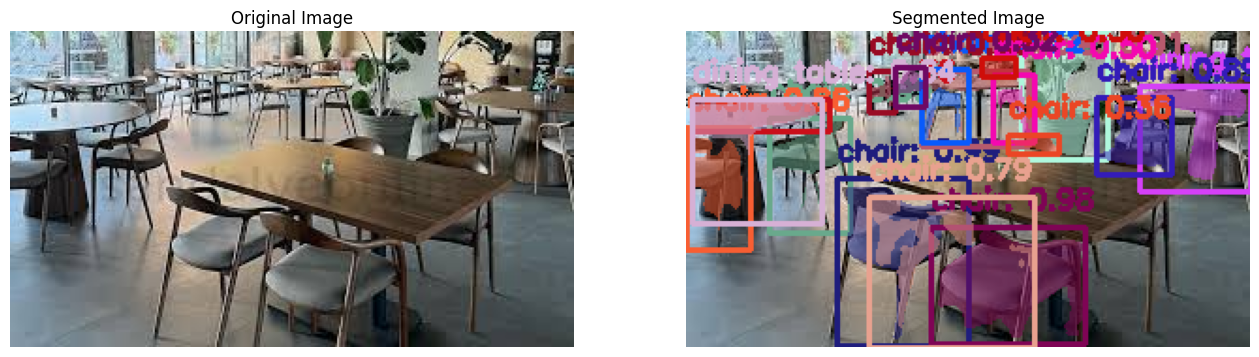

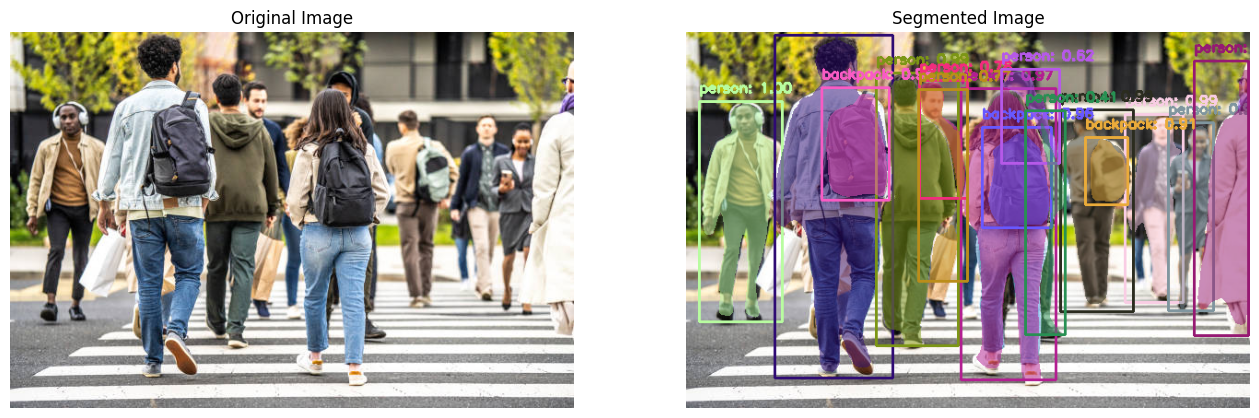

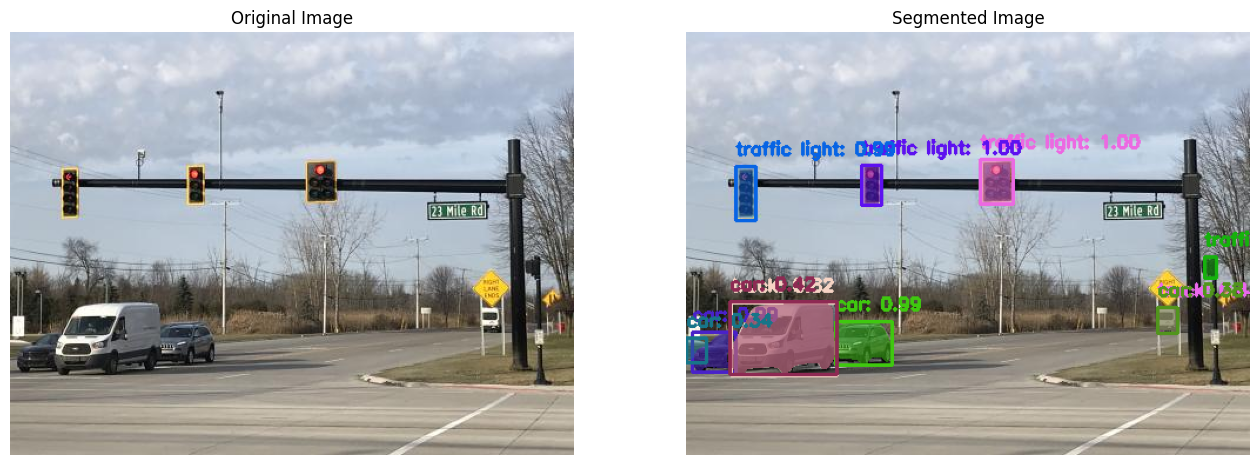

In [10]:
# Process each image with 0.3 thershold
for img in images:
    outputs = run_model(img)
    boxes, classes, scores, masks = extract_predictions(outputs)

    visualize_result(img, boxes, classes, scores, masks, threshold=0.3)